In [222]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

In [223]:
df = pd.read_csv("meteo_brest_194501202602/meteo_brest_194501202602.csv", sep=";")

In [224]:
df

,date,month_no,annee,Month,temperature_min_C,temperature_mean_C,temperature_max_C,pression_hPa,humidite_mm,ensollement_duree,ensolleillement_Wperm2,ensollei_min,vent_moy_kmperh,rafale_kmperh
0,01/01/1945,1,1945,JANVIER,-4.2,3.3,11.2,NaN,129.2,NaN,NaN,NaN,NaN,NaN
1,01/02/1945,2,1945,FEVRIER,-0.2,8.6,14.2,NaN,126.6,NaN,NaN,NaN,NaN,NaN
2,01/03/1945,3,1945,MARS,-1.6,7.9,20.6,NaN,20.9,NaN,NaN,NaN,NaN,NaN
3,01/04/1945,4,1945,AVRIL,2.6,11.6,26.5,NaN,50.5,NaN,NaN,NaN,NaN,NaN
4,01/05/1945,5,1945,MAI,0.0,12.7,24.8,NaN,70.7,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
969,01/10/2025,10,2025,OCTOBRE,3.3,12.9,20.6,987.1,109.4,104:01:00,781.0,6241.0,15.1,78.1
970,01/11/2025,11,2025,NOVEMBRE,0.9,11.0,19.8,981.3,118.1,52:29:00,485.0,3149.0,15.2,110.9
971,01/12/2025,12,2025,DECEMBRE,0.9,7.9,14.7,1004.7,87.3,31:07:00,419.0,1867.0,18.4,103.0
972,01/01/2026,1,2026,JANVIER,-4.9,7.1,12.5,970.6,317.4,37:10:00,431.0,2230.0,19.1,121.3


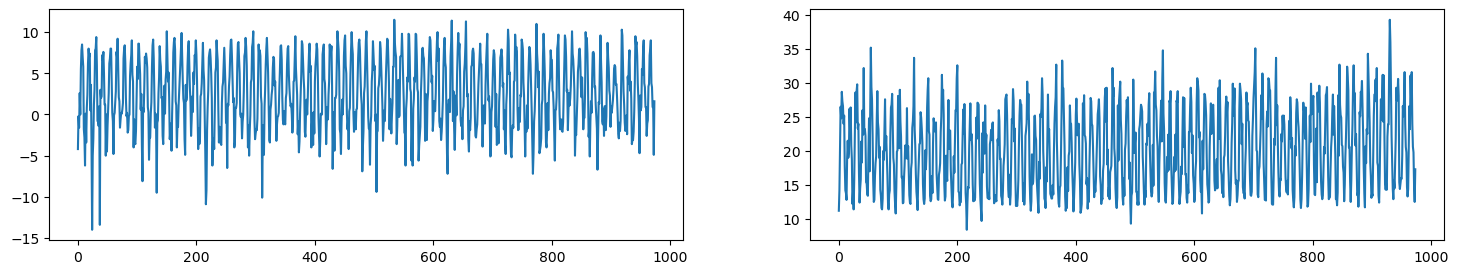

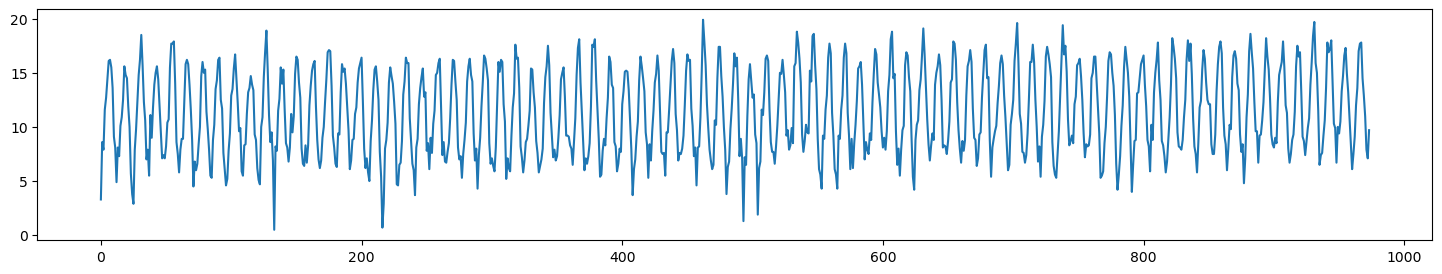

In [225]:
plt.figure(figsize=(18, 3))
plt.subplot(1, 2, 1)
plt.plot(df["temperature_min_C"])
plt.subplot(1, 2, 2)
plt.plot(df["temperature_max_C"])
plt.show()
plt.figure(figsize=(18, 3))
plt.plot(df["temperature_mean_C"])

In [226]:
def moving_avg(x, n):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[n:] - cumsum[:-n]) / float(n)

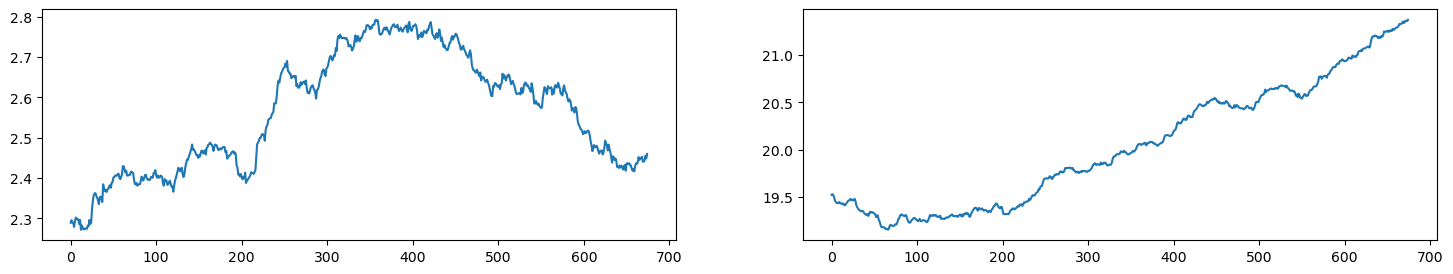

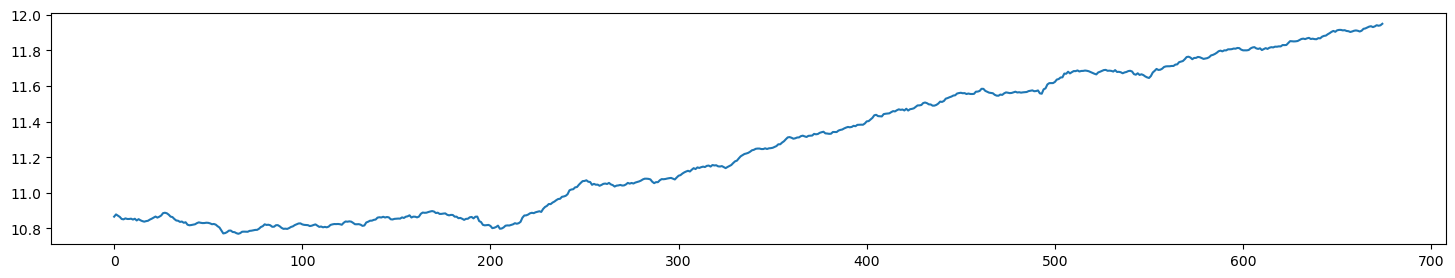

In [227]:
n = 12*25
plt.figure(figsize=(18, 3))
plt.subplot(1, 2, 1)
plt.plot(moving_avg(df["temperature_min_C"], n))
plt.subplot(1, 2, 2)
plt.plot(moving_avg(df["temperature_max_C"], n))
plt.show()
plt.figure(figsize=(18, 3))
plt.plot(moving_avg(df["temperature_mean_C"], n))

https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html

In [236]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [ ]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [233]:
adf_test(df["temperature_mean_C"])

Results of Dickey-Fuller Test:
Test Statistic                  -3.346518
p-value                          0.012923
#Lags Used                      22.000000
Number of Observations Used    951.000000
Critical Value (1%)             -3.437245
Critical Value (5%)             -2.864584
Critical Value (10%)            -2.568391
dtype: float64


In [235]:
kpss_test(df["temperature_mean_C"])

Results of KPSS Test:
Test Statistic           0.816637
p-value                  0.010000
Lags Used                1.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


/tmp/ipykernel_8541/1512460390.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


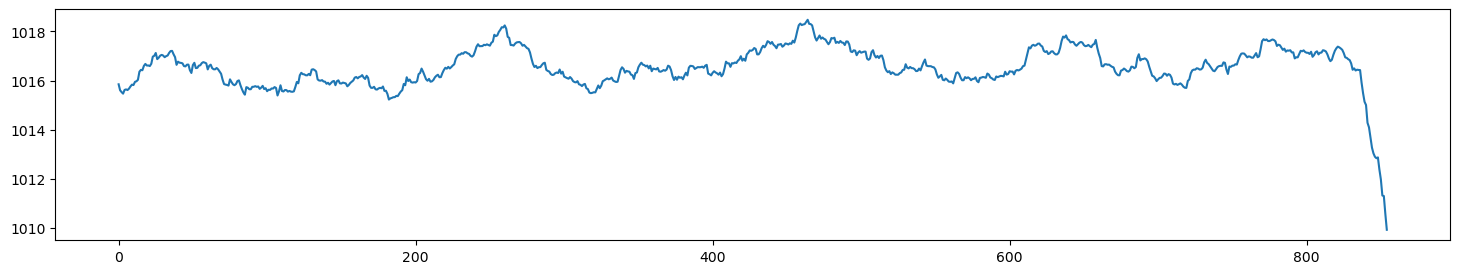

In [228]:
n = 12*5
plt.figure(figsize=(18, 3))
plt.plot(moving_avg(df["pression_hPa"][60:], n))

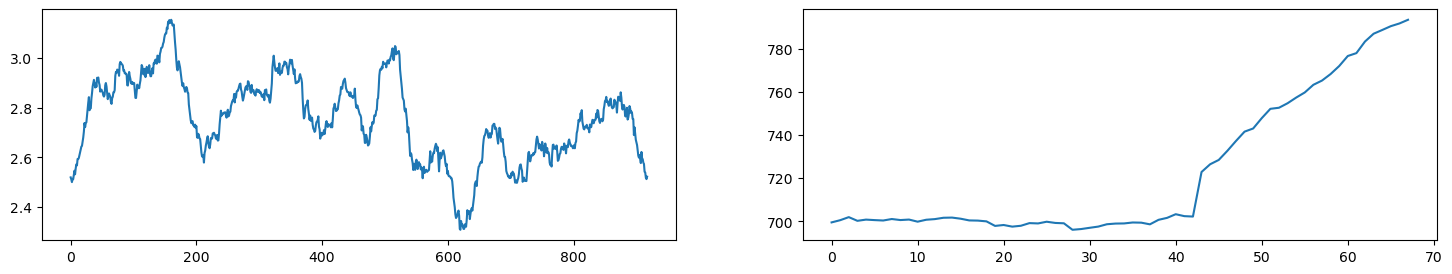

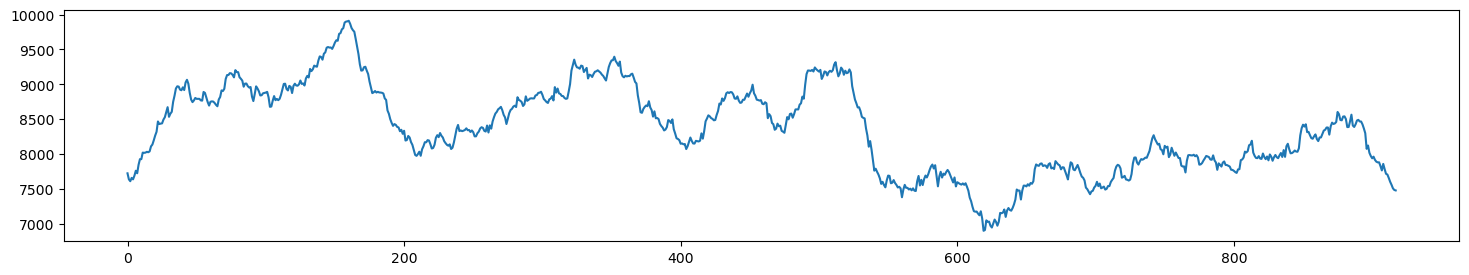

In [229]:
n = 12*4
plt.figure(figsize=(18, 3))
plt.subplot(1, 2, 1)
plt.plot(moving_avg(df["ensollement_duree"].str.split(':')[9:].apply(lambda x: int(x[0]) + int(x[1]))/60, n))
plt.subplot(1, 2, 2)
plt.plot(moving_avg(df["ensolleillement_Wperm2"][859:], n))
plt.show()
plt.figure(figsize=(18, 3))
plt.plot(moving_avg(df["ensollei_min"][9:], n))


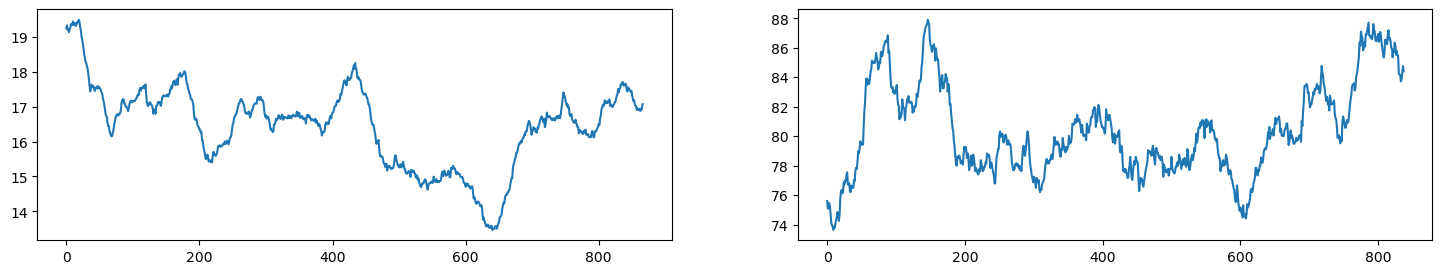

In [230]:
n = 12*4
plt.figure(figsize=(18, 3))
plt.subplot(1, 2, 1)
plt.plot(moving_avg(np.array(df["vent_moy_kmperh"][60:].apply(lambda x: float(x[:-1]) if x[-1] == 'k' else float(x))), n))
plt.subplot(1, 2, 2)
plt.plot(moving_avg(df["rafale_kmperh"][89:], n))
plt.show()

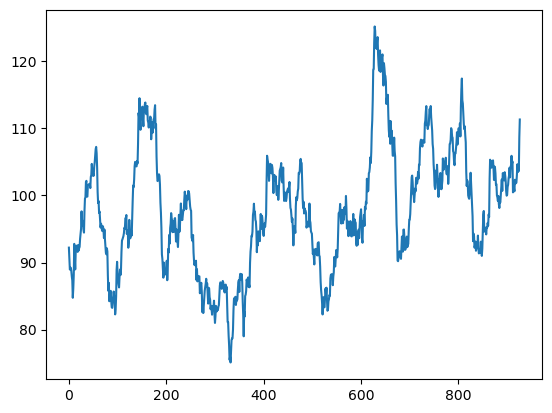

In [231]:
n = 12*4
plt.plot(moving_avg(df["humidite_mm"], n))